In [2]:
import os


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory, load_img, img_to_array 

2026-03-15 23:42:34.898877: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 23:42:34.947631: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
os.environ['KAGGLE_USERNAME'] = "XXXX"
os.environ['KAGGLE_KEY'] = "XXXXX"

import kaggle

# project was downloaded into a zip file, then exported into the "data" folder
# name of the file is "garbage-classification-v2.zip"
# the "original" folder is used, standardized_256 and standardized_384 folders with images are deleted since standarization is done in code
# zip is also deleted since it uses additional space

# as described, username and keys remain unseen for privacy reasons

# data folder remains seen so code in Google Colab can be executed

!kaggle datasets download -d sumn2u/garbage-classification-v2

Dataset URL: https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2
License(s): MIT
100%|██████████████████████████████████████| 1.07G/1.07G [04:52<00:00, 3.92MB/s]



In [2]:
data_dir = "../data/original"

- Images have different distributions among classes
- Imbalanced
    - todo: apply normalization of classes or some other technique

In [3]:
print("Num. observations")
shapes_list = []
labels = os.listdir(data_dir)
counter_imgs = 0
for label in labels:
   label_folder = data_dir+"/"+label
   image_paths = os.listdir(label_folder)
   counter_imgs += len(image_paths)
   print(label + ": " + str(len(image_paths)))
   shapes_per_label = []
   for path in image_paths:
      img_path = label_folder+"/"+path
      try:
         img = Image.open(img_path)
         shapes_per_label.append((img.width, img.height))
         img.verify()
      except Exception as e:
         print(f"corrupted: {path}")
   shapes_list.append(shapes_per_label)
   
print(str(counter_imgs))

Num. observations
clothes: 1984
biological: 810
trash: 494
paper: 1380
glass: 1998
battery: 814
shoes: 1633
metal: 993
plastic: 1709
cardboard: 1533
13348


- there are different shapes (image size) for all images:
    - todo: check what could be the best proportional size for all of them and define it for the input

In [4]:
[set(x) for x in shapes_list]

[{(400, 400),
  (400, 401),
  (400, 402),
  (400, 403),
  (400, 405),
  (400, 406),
  (400, 407),
  (400, 408),
  (400, 411),
  (400, 412),
  (400, 413),
  (400, 414),
  (400, 415),
  (400, 416),
  (400, 417),
  (400, 418),
  (400, 419),
  (400, 421),
  (400, 422),
  (400, 423),
  (400, 424),
  (400, 425),
  (400, 427),
  (400, 428),
  (400, 429),
  (400, 430),
  (400, 431),
  (400, 432),
  (400, 433),
  (400, 434),
  (400, 435),
  (400, 436),
  (400, 437),
  (400, 438),
  (400, 440),
  (400, 441),
  (400, 442),
  (400, 443),
  (400, 444),
  (400, 445),
  (400, 446),
  (400, 447),
  (400, 448),
  (400, 449),
  (400, 450),
  (400, 451),
  (400, 452),
  (400, 455),
  (400, 456),
  (400, 457),
  (400, 458),
  (400, 459),
  (400, 460),
  (400, 461),
  (400, 462),
  (400, 463),
  (400, 464),
  (400, 465),
  (400, 467),
  (400, 468),
  (400, 469),
  (400, 470),
  (400, 471),
  (400, 472),
  (400, 473),
  (400, 474),
  (400, 477),
  (400, 481),
  (400, 482),
  (400, 483),
  (400, 484),
  (400

In [9]:
dict_mean_shapes = {}
df_shapes = []
for e, shapes in enumerate(shapes_list):
    dft = pd.DataFrame(shapes)
    x,y = dft.median()
    dft.columns = ["width", "height"]
    dft["label"] = labels[e]
    df_shapes.append(dft)
    dict_mean_shapes[labels[e]] = (int(x),int(y))

,width,height,label
0,400,533,clothes
1,400,533,clothes
2,400,534,clothes
3,400,533,clothes
4,400,534,clothes
...,...,...,...
1528,512,384,cardboard
1529,560,560,cardboard
1530,300,300,cardboard
1531,225,225,cardboard


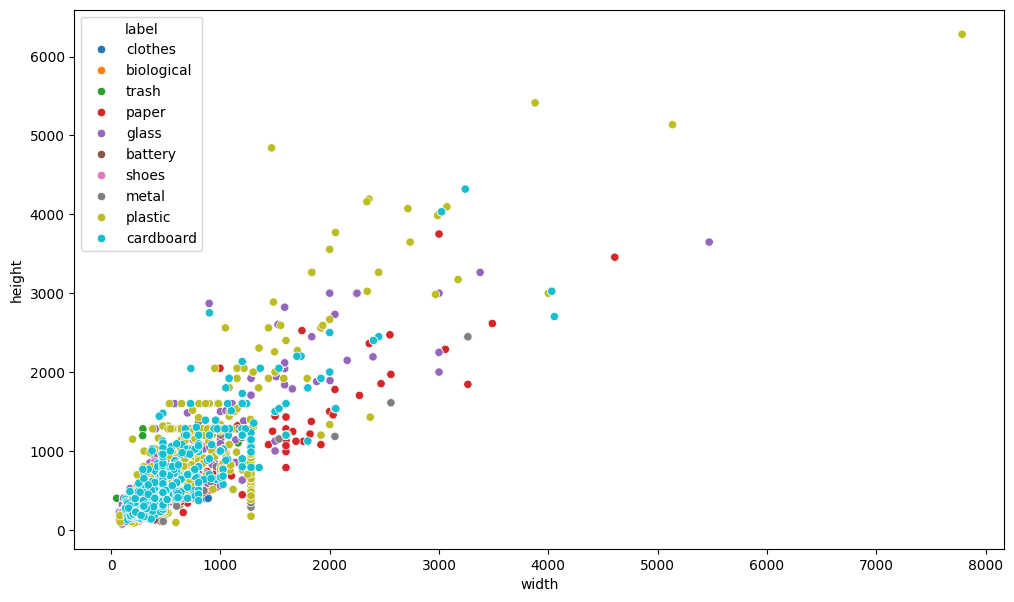

In [14]:
plt.figure(figsize = (12,7))

sns.scatterplot(data = pd.concat(df_shapes), x = "width", y = "height", hue = "label")

plt.show()

- based on this we can have a better idea on what size should we set the images for our model
- for now let's try (125, 125)

In [6]:
dict_mean_shapes

{'clothes': (400, 533),
 'biological': (274, 183),
 'trash': (300, 249),
 'paper': (512, 384),
 'glass': (266, 285),
 'battery': (225, 220),
 'shoes': (259, 225),
 'metal': (512, 384),
 'plastic': (512, 384),
 'cardboard': (474, 384)}

In [9]:

original_size = (125,125)
full_dataset = image_dataset_from_directory(
    data_dir,
    image_size=original_size,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

class_names = full_dataset.class_names

Found 13348 files belonging to 10 classes.


- Images look on full color, which may be useful to recognize shadow and relative positioning
- In particular for photos that don't have much information (like cardboard), color may be useful information for the model

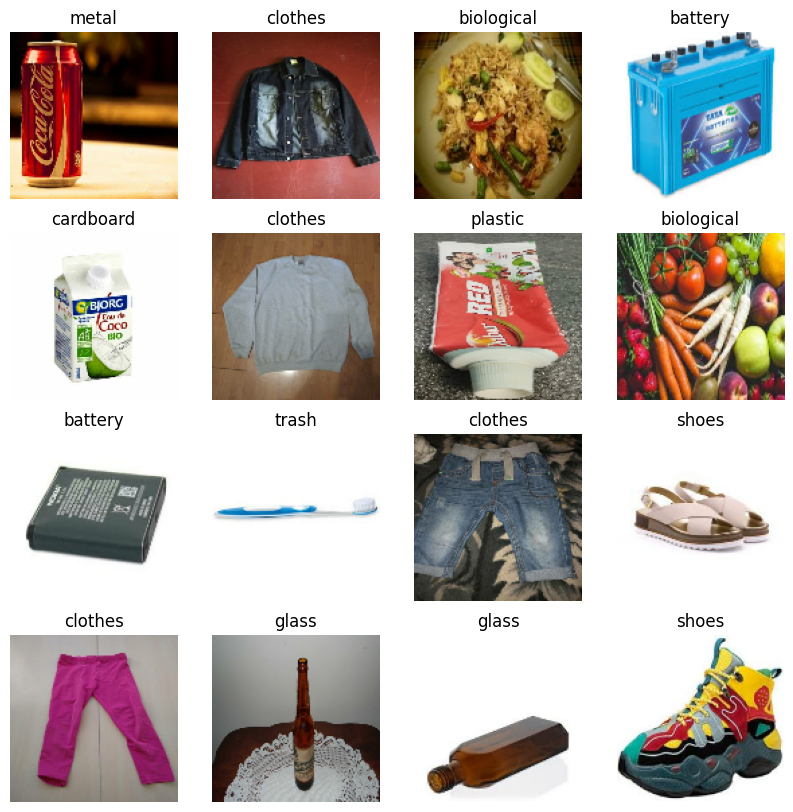

In [11]:
for images, labels in full_dataset.take(1):
    plt.figure(figsize=(10,10))
    
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

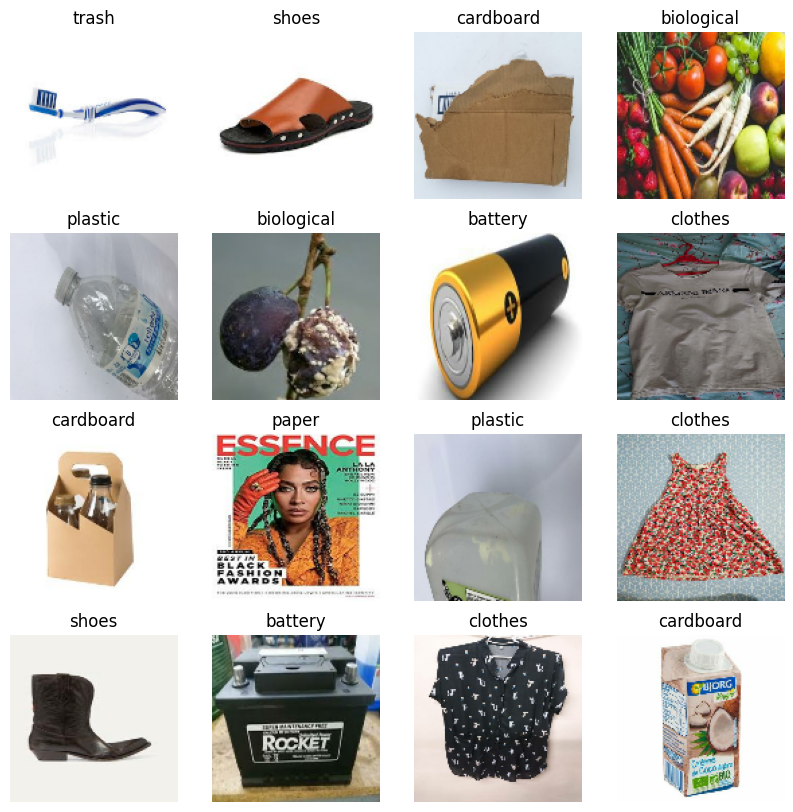

In [13]:
for images, labels in full_dataset.take(1):
    plt.figure(figsize=(10,10))
    
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

- Some of them, like paper or cardboard may have images on their cover, like a magazine or promotional images.
- These may prove to be a problem since our model may mistakenly predict it as another class:
    - For example: a beer bottle picture on cardboard gets labeled as "glass"

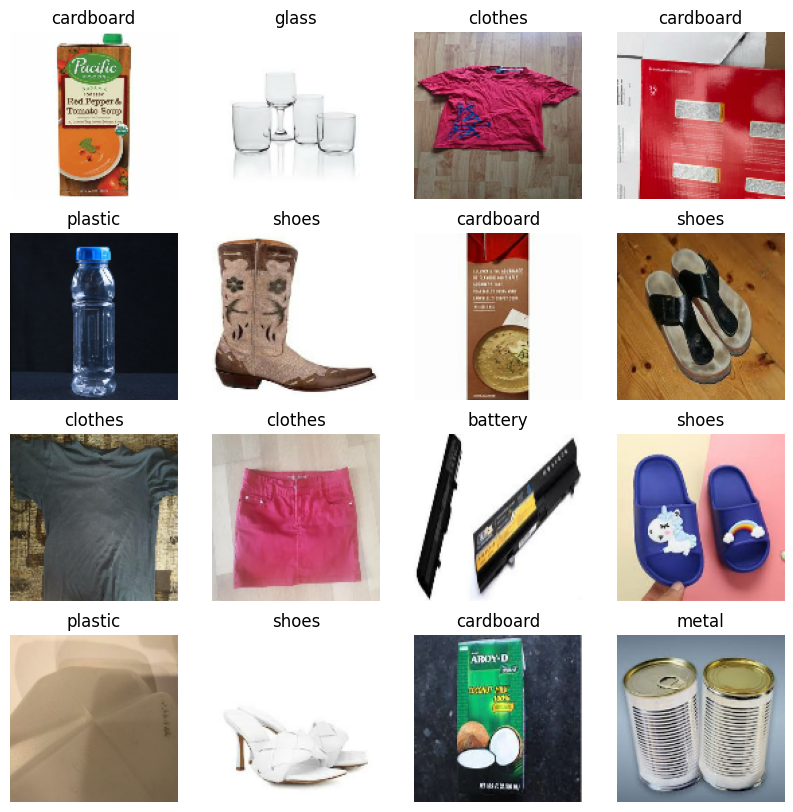

In [15]:
for images, labels in full_dataset.take(1):
    plt.figure(figsize=(10,10))
    
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

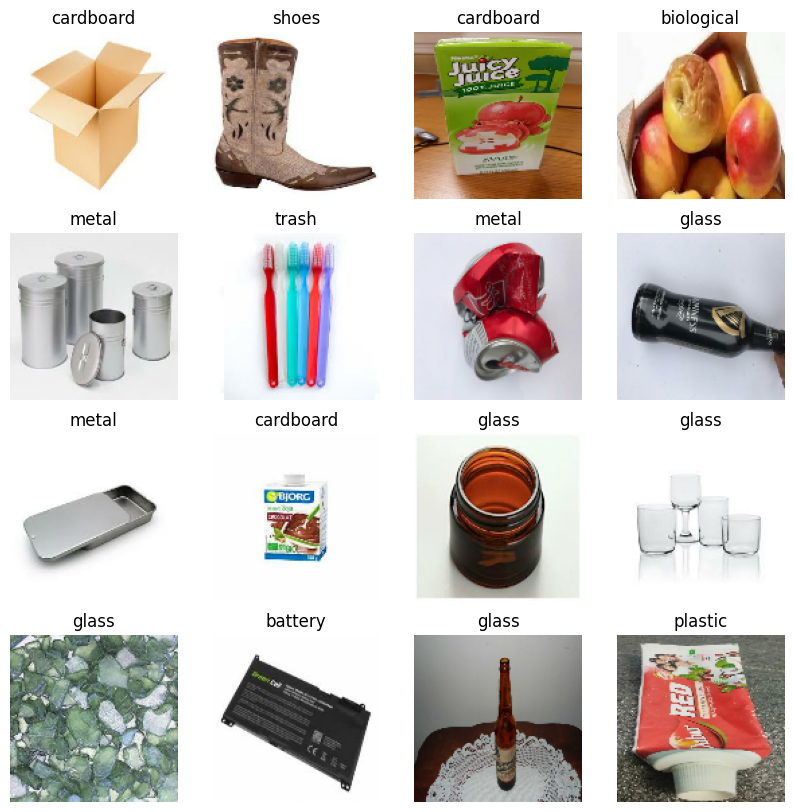

In [14]:
for images, labels in full_dataset.take(1):
    plt.figure(figsize=(10,10))
    
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

## Glass
- Broken glass: pieces of different colored broken glass
- Bottles, cups, etc.

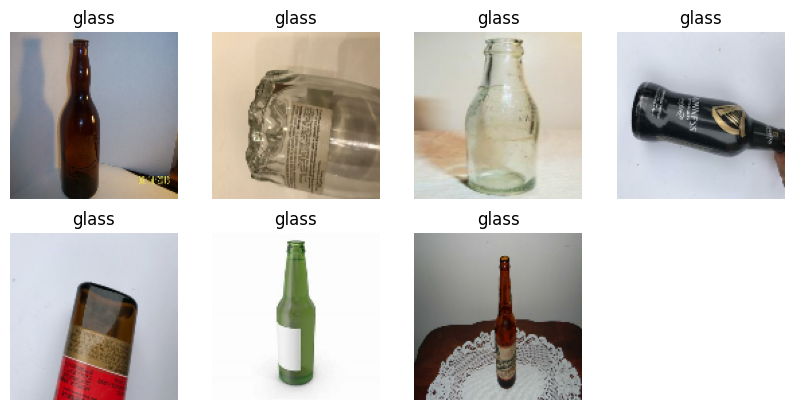

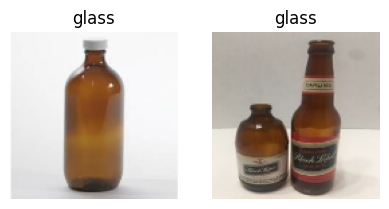

In [71]:
target_class = "glass"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(2):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

In [73]:
dict_mean_shapes

{'battery': (225, 220),
 'biological': (274, 183),
 'cardboard': (474, 384),
 'clothes': (400, 533),
 'glass': (266, 285),
 'metal': (512, 384),
 'paper': (512, 384),
 'plastic': (512, 384),
 'shoes': (259, 225),
 'trash': (300, 249)}

## Battery
- Small, car, computer, cellphone

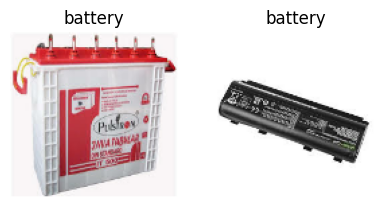

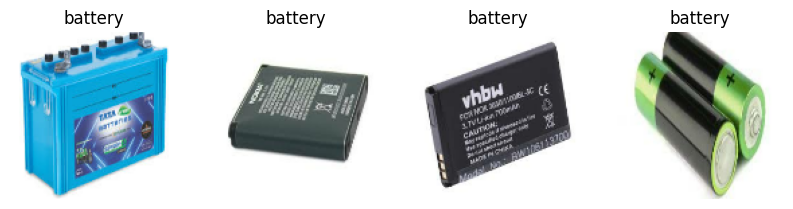

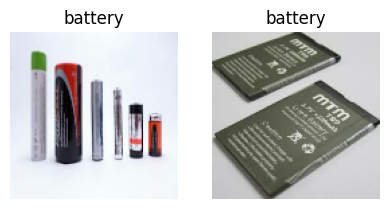

In [84]:
target_class = "battery"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

## Biological
- Food of various types: fruit, vegetables, pasta, bread
- Often moldy, a good portion of these seem to be rotten food
- Other portion seems to be residual food
- Not much "fresh" food

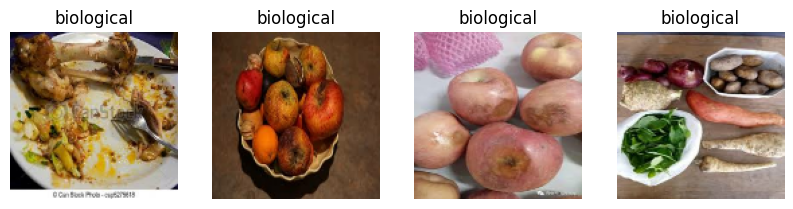

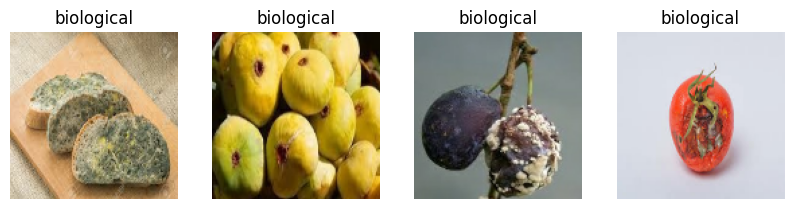

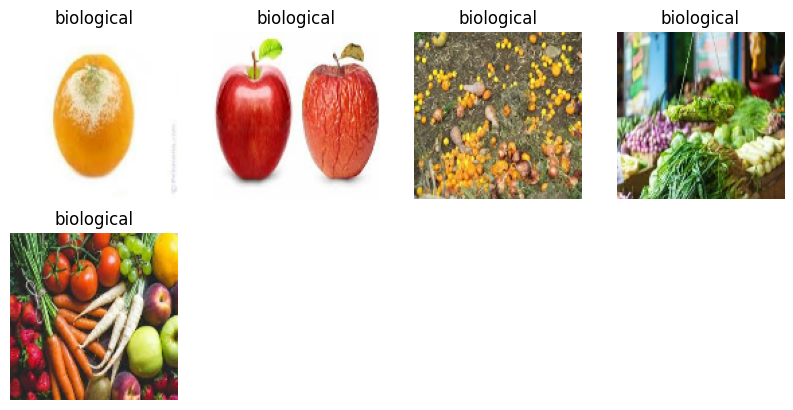

In [89]:
target_class = "biological"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

## Cardboard
- Plain brown cardboard
- Majority has promotional images on their cover
- Fruit, glasses, bottles
- This could interfere in the prediction of other classes

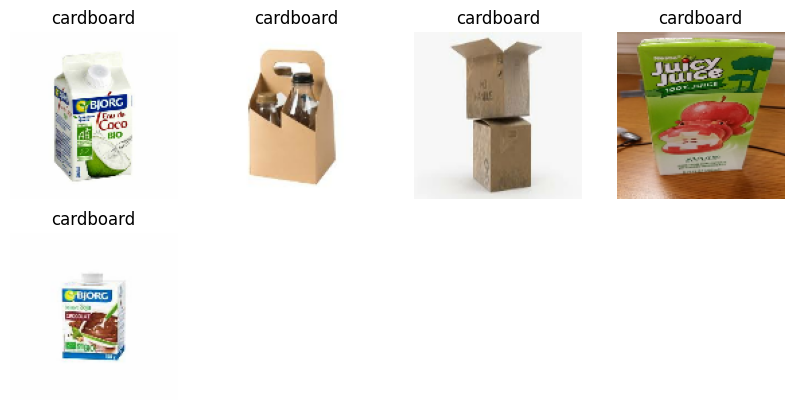

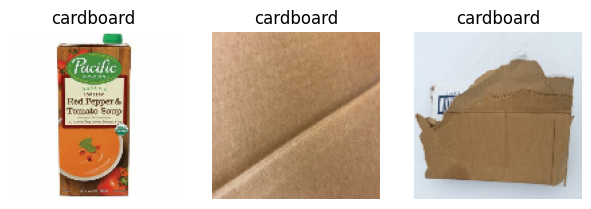

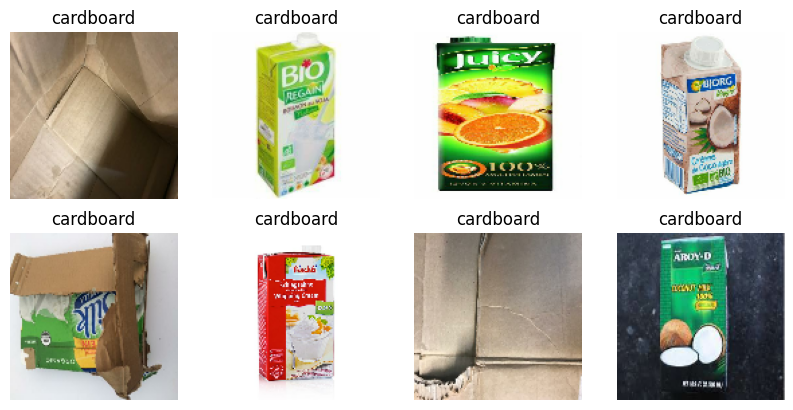

In [91]:
target_class = "cardboard"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

{'battery': (225, 220),
 'biological': (274, 183),
 'cardboard': (474, 384),
 'clothes': (400, 533),
 'glass': (266, 285),
 'metal': (512, 384),
 'paper': (512, 384),
 'plastic': (512, 384),
 'shoes': (259, 225),
 'trash': (300, 249)}

## Clothes
- Seems the most consistent: all images are pretty standard, not many variations
    - Photos are in general taken with the same angle
    - Clothing is well shown

- Possibly the class that will have the best performance (theory)

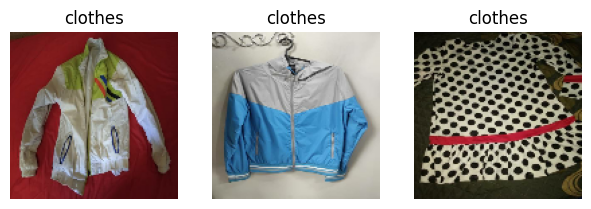

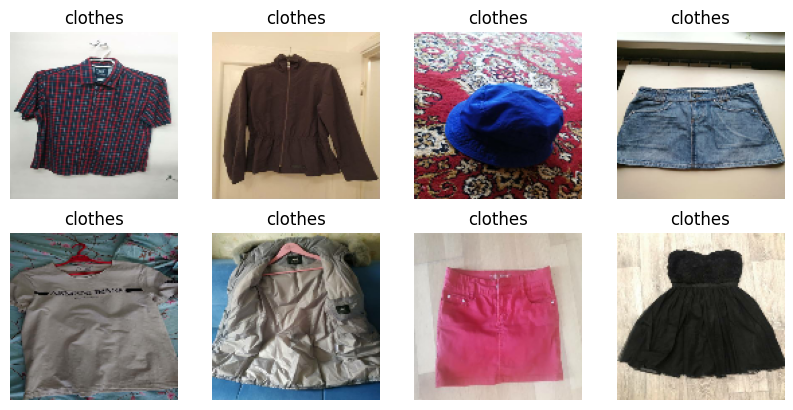

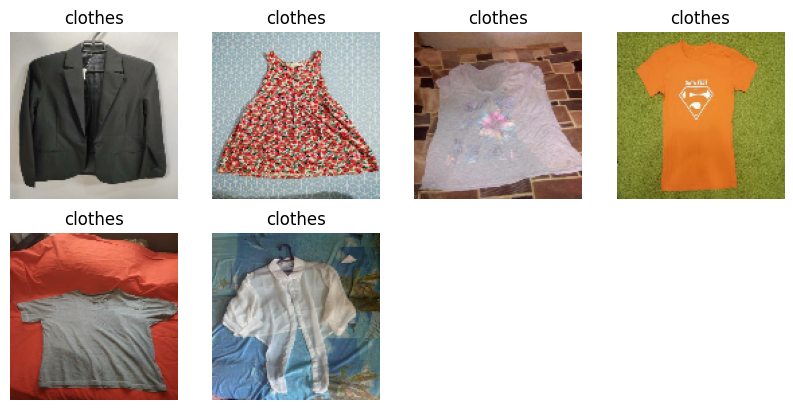

In [97]:
target_class = "clothes"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

## Metal
- cans, soda cans, alluminum foil
- there can be some overlapping with glass classes, similar between each other

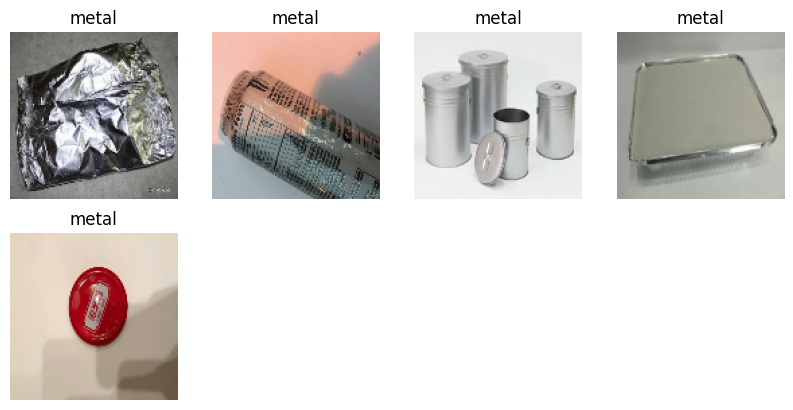

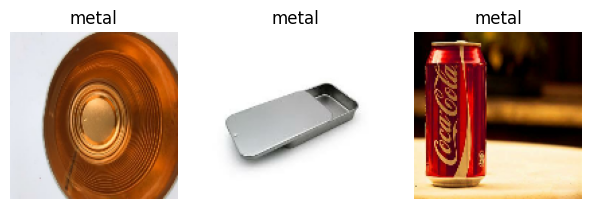

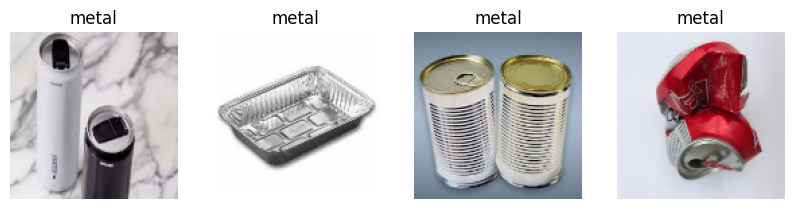

In [98]:
target_class = "metal"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

## Paper
- really similar to cardboard pictures
- can mistakenly be predicted with cardboard
- more content on top of these compared to cardboard, but still

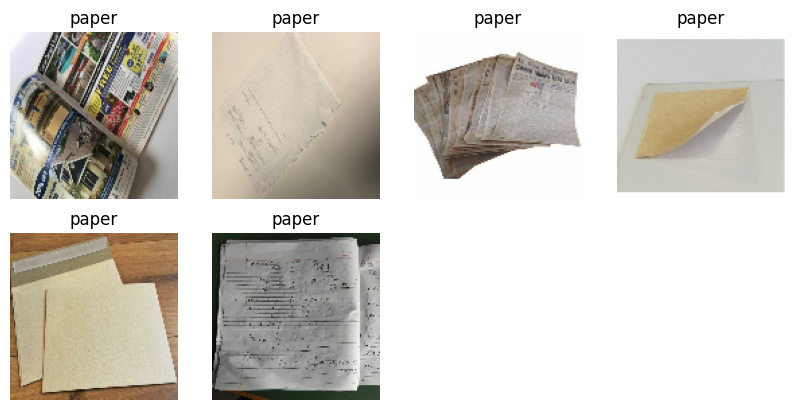

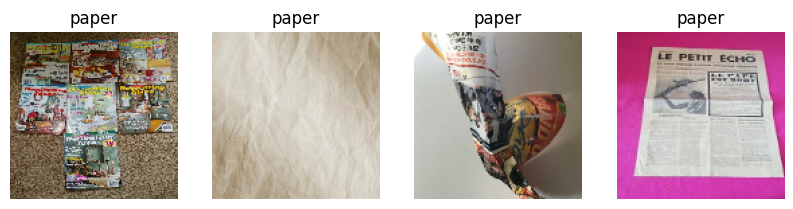

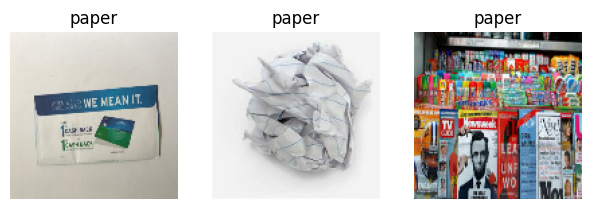

In [99]:
target_class = "paper"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

## Plastic
- Could be mistaken for glass
- depends on the picture, some of them have promotional on cover

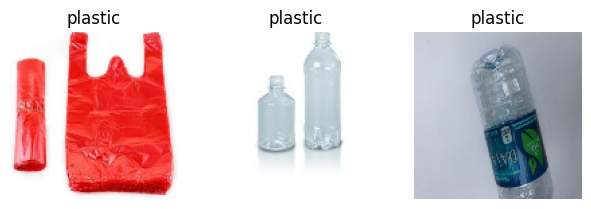

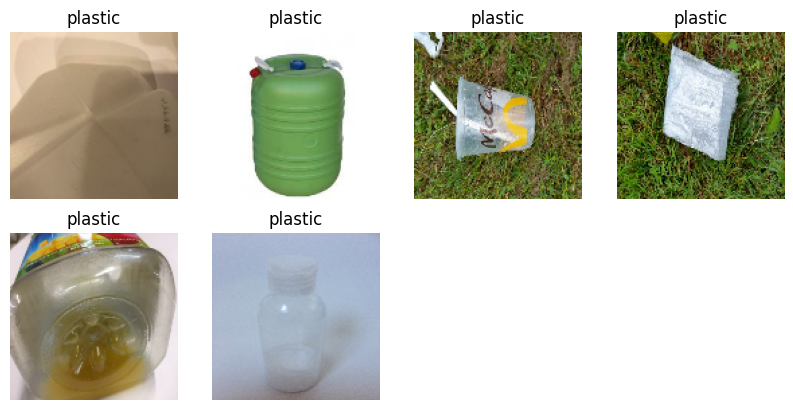

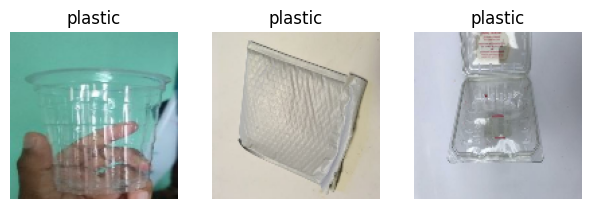

In [100]:
target_class = "plastic"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

## Shoes
- straight forward
- clean images, might be (with clothes) one of the class with better prediction accuracy

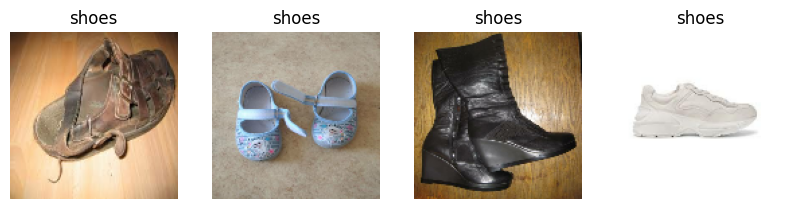

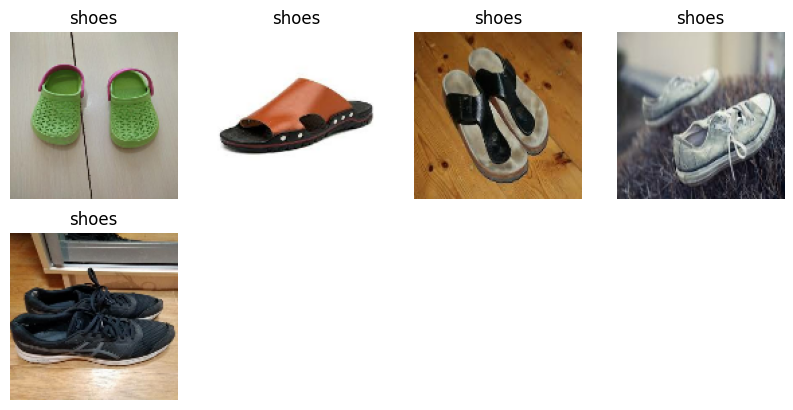

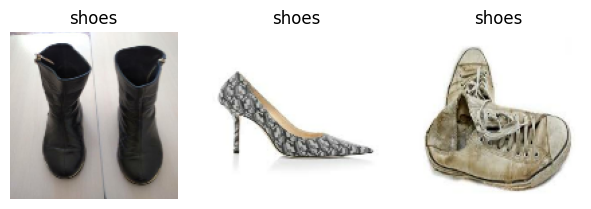

In [101]:
target_class = "shoes"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")

## Trash
- mix of items
- when model is unsure, this can be a good class to predict
- might be good

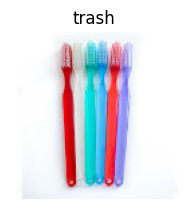

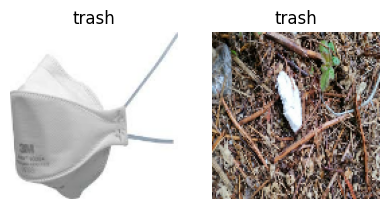

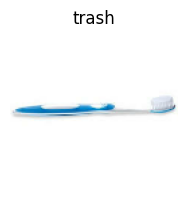

In [115]:
target_class = "trash"
target_index = class_names.index(target_class)

for images, labels in full_dataset.take(3):
    mask = np.argmax(labels.numpy(), axis=1) == target_index
    glass_images = images.numpy()[mask]

    plt.figure(figsize=(10,10))
    
    for i in range(min(16, len(glass_images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(glass_images[i].astype("uint8"))
        plt.title(target_class)
        plt.axis("off")